# Actividad: Entrenamiento con EfficientNetB0
Clasificación de calidad de limones usando el mismo dataset cargado desde Google Drive.

En esta actividad tendrá que completar los pasos faltantes en flujo del desarrollo del caso y responder las preguntas que se le realicen.

Esta actividad debera subirla en la plataforma.

Son 5 ejercicios.

***Puntuación:***

Cada ejercicio bien resuelto y sustentado: 3 puntos

Exposición: 5 puntos

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

## Carga del Dataset desde Google Drive (.zip)

In [2]:
#!pip install gdown
import gdown
import zipfile

url = "https://drive.google.com/file/d/1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx/view?usp=sharing"
file_id = url.split("/d/")[1].split("/")[0]
output = "lemon_dataset.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset cargado en carpeta 'dataset/'")

Downloading...
From (original): https://drive.google.com/uc?id=1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx
From (redirected): https://drive.google.com/uc?id=1-kJdc5I-vASkqjBnZpaWrZgpOSckptSx&confirm=t&uuid=0ae66cde-0f24-4884-8f27-17fa8ebbbd7d
To: c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\computer-vision\lemon_dataset.zip
100%|██████████| 244M/244M [00:06<00:00, 36.4MB/s] 


Dataset cargado en carpeta 'dataset/'


## Cargar dataset con ImageDataset

In [4]:
root_path = os.getcwd()

print(root_path)

c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\computer-vision


In [5]:
dataset_path = root_path + '/dataset'  # Ruta al dataset (cambiar si es otro caso)

train_ds = image_dataset_from_directory(
    os.path.join(dataset_path, 'lemon_dataset'),
    image_size=(128, 128), validation_split=0.2, subset='training',  batch_size=32, seed=42, label_mode='categorical')
val_ds = image_dataset_from_directory(
    os.path.join(dataset_path, 'lemon_dataset'),
    image_size=(128, 128), validation_split=0.2, subset='validation', batch_size=32, seed=42, label_mode='categorical')

class_names = train_ds.class_names

Found 2528 files belonging to 3 classes.
Using 2023 files for training.
Found 2528 files belonging to 3 classes.
Using 505 files for validation.


## Modelo EfficientNetB0 (Transfer Learning)

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Ejercicio 1

Ayudandose de herramientas de AI Generativa explique se es lo que significa el cuadro anterior.

Respuesta:

1. EfficientNetB0(..., include_top=False): Carga una red neuronal preentrenada con millones de imágenes (ImageNet) para extraer características visuales, pero le quita su "cabeza" original (la capa de clasificación final).

2. base_model.trainable = False: Congela el modelo base para que no pierda el conocimiento que ya tiene durante el entrenamiento.

3. models.Sequential([...]): Crea una nueva estructura secuencial combinando:

    - El modelo base congelado.

    - GlobalAveragePooling2D(): Reduce las dimensiones espaciales de la imagen a un vector plano.

    - Dropout(0.3): Apaga al azar el 30% de las neuronas para evitar el sobreajuste (overfitting).

    - Dense(..., activation='softmax'): La nueva capa de salida adaptada a tu número de clases (len(class_names)), que en tu caso es 3.

4. model.compile(...): Configura el modelo para entrenar usando el optimizador Adam y la función de pérdida ideal para clasificación multiclase.

Interpretacion de la tabla:
Detalla elflujo de los datos y el conteo de parametros

**Flujo de las capas: **

- efficientnetb0: Recibe la imagen y entrega un mapa de características de $4 \times 4$ con 1,280 canales. Contiene 4,049,571 parámetros.
- global_average_pooling2d: Promedia los mapas de $4 \times 4$, reduciendo la salida a un vector simple de 1,280 elementos (no tiene parámetros que aprender).
- dropout: Mantiene la misma forma de 1,280 elementos (tampoco tiene parámetros).
- dense: Transforma los 1,280 elementos en 3 (las 3 clases a predecir). Esto requiere $1,280 \times 3 + 3 \text{ (biases)} = 3,843$ parámetros.

### Ejercicio 2
En una primera iteración ejecute el modelo usando epochs = 5

En una segunda iteración ejecute el modelo usando epochs = 10

¿Qué diferencias percibe?

Respuesta:


## **Entrenamiento** del modelo

In [11]:
%%time
# para medir el tiempo de ejecución total usaremos %%time

epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9871 - loss: 0.0446 - val_accuracy: 0.9861 - val_loss: 0.0359
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.9871 - loss: 0.0417 - val_accuracy: 0.9881 - val_loss: 0.0328
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9881 - loss: 0.0393 - val_accuracy: 0.9861 - val_loss: 0.0338
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9911 - loss: 0.0356 - val_accuracy: 0.9881 - val_loss: 0.0313
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9886 - loss: 0.0345 - val_accuracy: 0.9881 - val_loss: 0.0296
CPU times: total: 4min 49s
Wall time: 50.6 s


## Curvas de entrenamiento

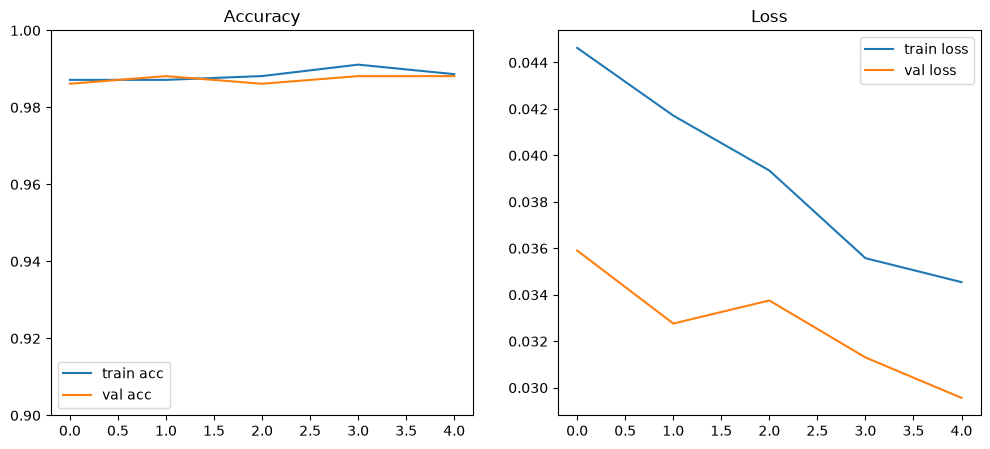

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.legend()
plt.title('Accuracy')
plt.ylim(0.9,1)

plt.subplot(1,2,2)
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

## Métricas y Matriz de Confusión

### Ejercicio 3
Calcula la matriz de confusión y las metricas en la data de validación (val_ds)

Pista: Buscar confusion_matrix o classification_report

Nota: En caso le salga error, solucionelo con ayuda de herramientas de AI Generativa como Gemini en colab o Chat GPT


Matriz de confusión:


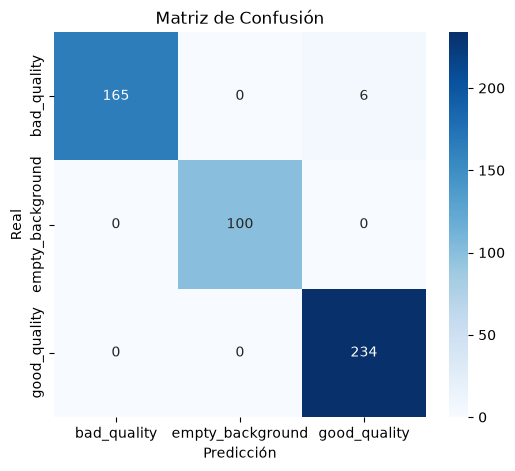


Reporte de clasificación:
                  precision    recall  f1-score   support

     bad_quality     1.0000    0.9649    0.9821       171
empty_background     1.0000    1.0000    1.0000       100
    good_quality     0.9750    1.0000    0.9873       234

        accuracy                         0.9881       505
       macro avg     0.9917    0.9883    0.9898       505
    weighted avg     0.9884    0.9881    0.9881       505


Accuracy real calculado correctamente: 0.9881


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print("Matriz de confusión:")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()
print("\nReporte de clasificación:")
print(report)

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)

accuracy = (y_true == y_pred).mean()
print(f"\nAccuracy real calculado correctamente: {accuracy:.4f}")

### Ejercicio 4
4a. Calcula la matriz de confusión y las metricas en la data de train (train_ds)

4b. ¿El modelo esta sobreajustado?

**Sobreajuste:** Ocurre cuando un modelo aprende demasiado los detalles del conjunto de entrenamiento (como si los memorizara) y pierde capacidad para generalizar a datos nuevos.
***Ejemplo:*** En entrenamiento tiene 98% de acierto, pero en validación solo 75%.


4c. ¿Cómo interpretas el precision y el recall de la categoría de bad_quality?

Matriz de confusión (train):


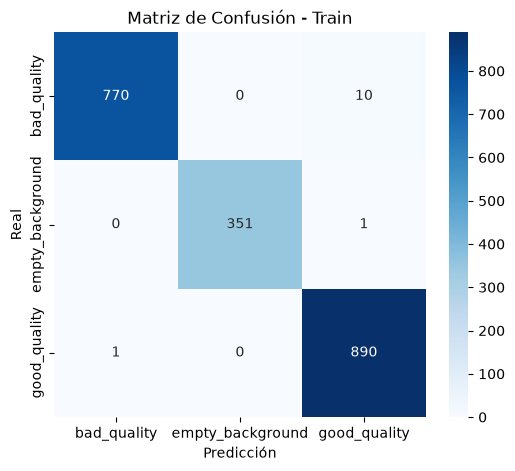


Reporte de clasificación (train):
                  precision    recall  f1-score   support

     bad_quality     0.9987    0.9872    0.9929       780
empty_background     1.0000    0.9972    0.9986       352
    good_quality     0.9878    0.9989    0.9933       891

        accuracy                         0.9941      2023
       macro avg     0.9955    0.9944    0.9949      2023
    weighted avg     0.9941    0.9941    0.9941      2023


Accuracy real calculado correctamente (train): 0.9941


In [18]:
y_true_train = []
y_pred_train = []

for x_batch, y_batch in train_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true_train.extend(np.argmax(y_batch, axis=1))
    y_pred_train.extend(np.argmax(preds, axis=1))

cm_train = confusion_matrix(y_true_train, y_pred_train)
report_train = classification_report(y_true_train, y_pred_train,
                                     target_names=class_names, digits=4)

print("Matriz de confusión (train):")
plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Train")
plt.show()

print("\nReporte de clasificación (train):")
print(report_train)

y_true_train  = np.array(y_true_train)
y_pred_train  = np.array(y_pred_train)

accuracy_train = (y_true_train == y_pred_train).mean()
print(f"\nAccuracy real calculado correctamente (train): {accuracy_train:.4f}")

In [ ]:
# COMPLETAR 4a



Respuesta:

4b.

4c.

### Ejercicio 5

¿Qué modelos en los que se uso transferlearning elegirias? Justifique.

Opción 1: MobileNetV2

Opción 2: EfficientNetB0

Respuesta:

Empleando el mismo dataset con ambos modelos se obtiene los siguientes resultados:

Opción 1: MobileNetV2

- Accuracy real calculado correctamente: 0.9842
- Accuracy real calculado correctamente (train): 0.9911

Opción 2: EfficientNetB0

- Accuracy real calculado correctamente: 0.9881
- Accuracy real calculado correctamente (train): 0.9941

## Inferencia sobre imágenes nuevas

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_image(img_path):
    # 1. Cargar imagen en RGB y redimensionar igual que en el dataset
    img = load_img(img_path, target_size=(128, 128), color_mode="rgb")

    # 2. Convertir a array (0–255, float32)
    arr = img_to_array(img)           # shape: (128,128,3)

    # 3. Añadir dimensión batch, SIN dividir entre 255
    arr = np.expand_dims(arr, axis=0) # shape: (1,128,128,3)

    # 4. Predecir
    probs = model.predict(arr, verbose=0)[0]  # vector de probabilidades
    idx = np.argmax(probs)

    return class_names[idx], probs


In [ ]:
# Ejemplo:
predict_image('dataset/lemon_dataset/bad_quality/bad_quality_105.jpg')